# Data Exploration & Analysis

Comprehensive exploration of the LinkedIn job extraction dataset.

**Dataset:** 500 LinkedIn posts with ground truth annotations

**Objectives:**
1. Understand data distribution
2. Analyze category balance
3. Explore text characteristics
4. Identify potential challenges

In [1]:
# DEPENDENCIES
import json
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Imports complete")


Imports complete


## Load Dataset

In [2]:
# Load raw data
with open('../data/raw/linkedin_posts_500_new.json', 'r', encoding = 'utf-8') as f:
    raw_data = json.load(f)

# Load ground truth annotations
with open('../data/annotations/ground_truth_500.json', 'r', encoding = 'utf-8') as f:
    annotations = json.load(f)

print(f"Raw data samples: {len(raw_data)}")
print(f"Annotated samples: {len(annotations)}")

# Convert to DataFrame
df = pd.DataFrame(data = annotations)
df.head()


Raw data samples: 500
Annotated samples: 500


,post_id,name,about,description,userProfileUrl,source,searchJobTitle,companyLinks,category,is_relevant,extracted_people,extracted_companies,extracted_roles,annotator,annotation_date
0,post_001,Emily Davis,HR Director | Talent Acquisition,We're pleased to announce that David Brown has...,https://linkedin.com/in/emily-davis,LinkedIn,Chief Technology Officer,[https://fintechglobal.com],1,True,[David Brown],[FinTech Global],[Chief Technology Officer],expert_annotator_1,2026-02-04
1,post_002,Sarah Johnson,Senior Data Scientist | Consulting Expert,Excited to share that James Taylor has joined ...,https://linkedin.com/in/sarah-johnson,LinkedIn,Senior Data Scientist,[https://cloudsolutions.com],1,True,[James Taylor],[CloudSolutions],[Senior Data Scientist],expert_annotator_1,2026-02-04
2,post_003,Emily Davis,Senior Professional | Finance,I'm thrilled to announce that I'm starting a n...,https://linkedin.com/in/emily-davis,LinkedIn,Senior Software Engineer,[https://datasystemsinc.com],1,True,[Jane Doe],[DataSystems Inc],[Senior Software Engineer],expert_annotator_1,2026-02-04
3,post_004,Robert Wilson,Chief Financial Officer | Technology Expert,Excited to share that Jane Doe has joined our ...,https://linkedin.com/in/robert-wilson,LinkedIn,Chief Financial Officer,[https://datasystemsinc.com],1,True,[Jane Doe],[DataSystems Inc],[Chief Financial Officer],expert_annotator_1,2026-02-04
4,post_005,Sarah Johnson,Technology Leader,"After an incredible journey, I'm transitioning...",https://linkedin.com/in/sarah-johnson,LinkedIn,Chief Technology Officer,[https://techcorp.com],2,True,[Jane Doe],[TechCorp],[Chief Technology Officer],expert_annotator_1,2026-02-04


## Dataset Overview

In [3]:
# Basic statistics
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Total samples: {len(df)}")
print(f"\nRelevance distribution:")
print(df['is_relevant'].value_counts())
print(f"\nCategory distribution:")
print(df['category'].value_counts().sort_index())
print("\nDataFrame info:")
df.info()

DATASET STATISTICS
Total samples: 500

Relevance distribution:
is_relevant
True     350
False    150
Name: count, dtype: int64

Category distribution:
category
1    300
2     50
5    150
Name: count, dtype: int64

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   post_id              500 non-null    object
 1   name                 500 non-null    object
 2   about                500 non-null    object
 3   description          500 non-null    object
 4   userProfileUrl       500 non-null    object
 5   source               500 non-null    object
 6   searchJobTitle       500 non-null    object
 7   companyLinks         500 non-null    object
 8   category             500 non-null    int64 
 9   is_relevant          500 non-null    bool  
 10  extracted_people     500 non-null    object
 11  extracted_companies  50

## Category Distribution

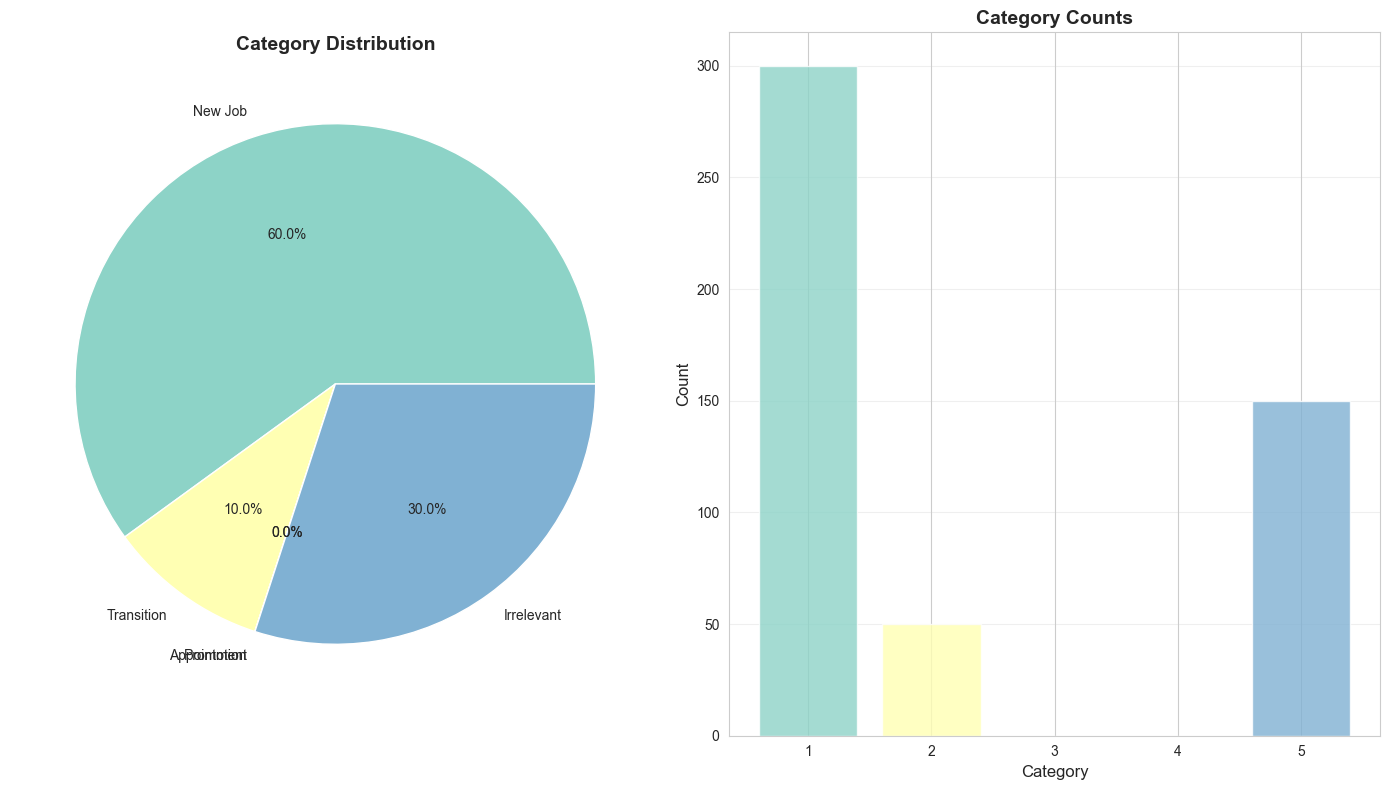

Category distribution plot saved


In [7]:
# Plot category distribution
fig, axes       = plt.subplots(nrows   = 1, 
                               ncols   = 2, 
                               figsize = (14, 8),
                              )

# Pie chart
category_counts = df['category'].value_counts().sort_index()
category_map    = {1 : 'New Job',
                   2 : 'Transition',
                   3 : 'Promotion',
                   4 : 'Appointment',
                   5 : 'Irrelevant',
                  }

category_counts = (category_counts.reindex(category_map.keys(), fill_value=0))

category_labels = list(category_map.values())
colors          = sns.color_palette('Set3', len(category_counts))

axes[0].pie(category_counts, 
            labels  = category_labels, 
            autopct = '%1.1f%%', 
            colors  = colors,
           )

axes[0].set_title('Category Distribution', 
                  fontsize   = 14, 
                  fontweight = 'bold',
                 )

# Bar chart
axes[1].bar(range(1, 6), 
            category_counts, 
            color = colors, 
            alpha = 0.8,
           )

axes[1].set_xlabel('Category', fontsize = 12)
axes[1].set_ylabel('Count', fontsize = 12)
axes[1].set_title('Category Counts', 
                  fontsize   = 14, 
                  fontweight = 'bold',
                 )

axes[1].set_xticks(range(1, 6))
axes[1].grid(axis  = 'y', 
             alpha = 0.3,
            )

plt.tight_layout()
plt.savefig(fname       = 'experiment_results/category_distribution.png', 
            dpi         = 300, 
            bbox_inches = 'tight',
           )

plt.show()

print("Category distribution plot saved")


## Text Length Analysis

In [18]:
# Calculate text lengths
df['description_length'] = df['description'].apply(len)
df['description_words'] = df['description'].apply(lambda x: len(x.split()))

# Statistics by category
print("Text length statistics by category:")
df.groupby('category')[['description_length', 'description_words']].describe()

Text length statistics by category:


description_length                                                    \
                      count        mean        std   min    25%    50%    75%   
category                                                                        
1                     300.0  110.833333  12.276588  85.0  102.0  111.0  119.0   
2                      50.0  101.120000   5.415925  87.0   99.0  102.0  105.0   
5                     150.0   76.033333  11.345352  60.0   68.0   70.0   83.0   

                description_words                                           \
            max             count   mean       std   min   25%   50%   75%   
category                                                                     
1         133.0             300.0  18.10  1.320028  16.0  17.0  18.0  19.0   
2         107.0              50.0  15.90  0.707107  15.0  15.0  16.0  16.0   
5         100.0             150.0  12.08  2.392718   8.0  11.0  13.0  14.0   

                
           max  
category        
1         20.0  
2         17.0  
5         15.0

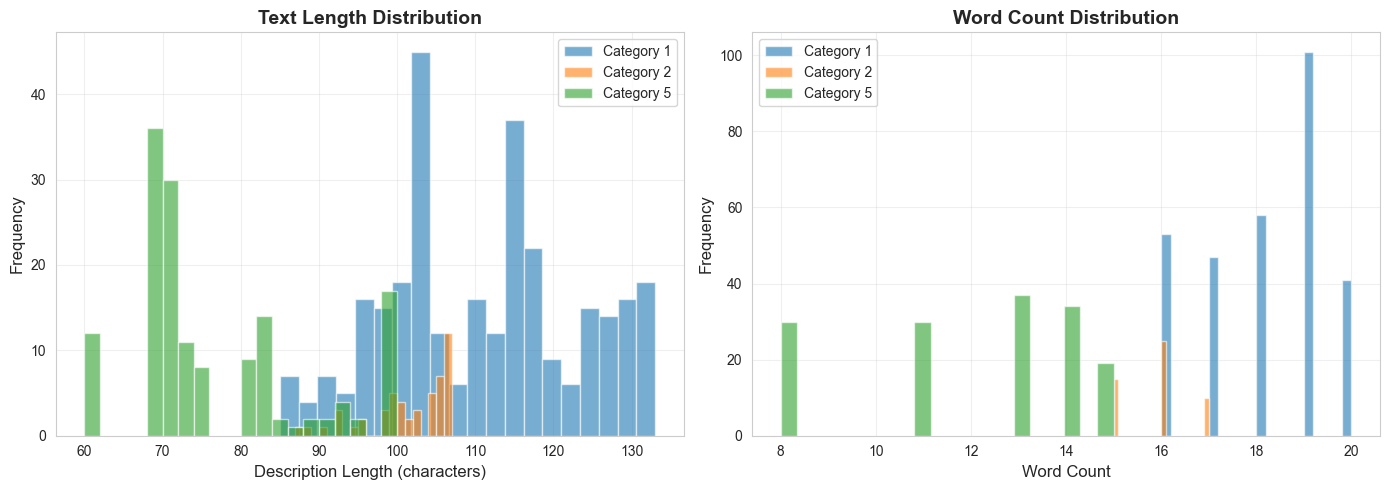

✓ Text length distribution plot saved


In [9]:
# Plot text length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length
for cat in sorted(df['category'].unique()):
    data = df[df['category'] == cat]['description_length']
    axes[0].hist(data, alpha=0.6, label=f'Category {cat}', bins=20)

axes[0].set_xlabel('Description Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Word count
for cat in sorted(df['category'].unique()):
    data = df[df['category'] == cat]['description_words']
    axes[1].hist(data, alpha=0.6, label=f'Category {cat}', bins=20)

axes[1].set_xlabel('Word Count', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_results/text_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Text length distribution plot saved")

## Entity Analysis

In [10]:
# Count entities per post
df['num_people'] = df['extracted_people'].apply(len)
df['num_companies'] = df['extracted_companies'].apply(len)
df['num_roles'] = df['extracted_roles'].apply(len)

# Statistics
print("Entity counts per post:")
print(f"Average people mentioned: {df['num_people'].mean():.2f}")
print(f"Average companies mentioned: {df['num_companies'].mean():.2f}")
print(f"Average roles mentioned: {df['num_roles'].mean():.2f}")
print(f"\nPosts with multiple job changes: {(df['num_people'] > 1).sum()}")

Entity counts per post:
Average people mentioned: 0.70
Average companies mentioned: 0.70
Average roles mentioned: 0.70

Posts with multiple job changes: 0


In [11]:
# Most common entities
all_people = [person for people_list in df['extracted_people'] for person in people_list]
all_companies = [company for company_list in df['extracted_companies'] for company in company_list]
all_roles = [role for role_list in df['extracted_roles'] for role in role_list]

print("\nMost common person names:")
print(Counter(all_people).most_common(10))

print("\nMost common companies:")
print(Counter(all_companies).most_common(10))

print("\nMost common roles:")
print(Counter(all_roles).most_common(10))


Most common person names:
[('James Taylor', 77), ('Jane Doe', 76), ('David Brown', 70), ('Maria Garcia', 70), ('Lisa Anderson', 57)]

Most common companies:
[('FinTech Global', 79), ('TechCorp', 72), ('DataSystems Inc', 71), ('InnovateLabs', 68), ('CloudSolutions', 60)]

Most common roles:
[('Senior Data Scientist', 53), ('VP of Sales', 52), ('Senior Software Engineer', 45), ('Chief Financial Officer', 45), ('Director of Operations', 45), ('VP of Engineering', 38), ('Chief Technology Officer', 36), ('Head of Product', 36)]


## Sample Posts by Category

In [12]:
# Show example from each category
for cat in sorted(df['category'].unique()):
    print(f"\n{'='*80}")
    print(f"CATEGORY {cat} EXAMPLE")
    print(f"{'='*80}")
    
    sample = df[df['category'] == cat].iloc[0]
    
    print(f"\nPoster: {sample['name']}")
    print(f"Description: {sample['description'][:200]}...")
    print(f"\nRelevant: {sample['is_relevant']}")
    print(f"People: {sample['extracted_people']}")
    print(f"Companies: {sample['extracted_companies']}")
    print(f"Roles: {sample['extracted_roles']}")


CATEGORY 1 EXAMPLE

Poster: Emily Davis
Description: We're pleased to announce that David Brown has joined FinTech Global as Chief Technology Officer. Looking forward to great things!...

Relevant: True
People: ['David Brown']
Companies: ['FinTech Global']
Roles: ['Chief Technology Officer']

CATEGORY 2 EXAMPLE

Poster: Sarah Johnson
Description: After an incredible journey, I'm transitioning to a new role as Chief Technology Officer at TechCorp....

Relevant: True
People: ['Jane Doe']
Companies: ['TechCorp']
Roles: ['Chief Technology Officer']

CATEGORY 5 EXAMPLE

Poster: Kevin Lee
Description: We're hiring for a Marketing Manager position at GlobalCorp. Apply now if you're interested!...

Relevant: False
People: []
Companies: []
Roles: []


## Data Quality Checks

In [13]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for empty descriptions
empty_desc = df[df['description'].str.strip() == '']
print(f"\nEmpty descriptions: {len(empty_desc)}")

# Check consistency
relevant_posts = df[df['is_relevant'] == True]
posts_with_entities = relevant_posts[relevant_posts['num_people'] > 0]
print(f"\nRelevant posts: {len(relevant_posts)}")
print(f"Relevant posts with extracted people: {len(posts_with_entities)}")
print(f"Consistency: {len(posts_with_entities) / len(relevant_posts) * 100:.1f}%")

Missing values:
post_id                0
name                   0
about                  0
description            0
userProfileUrl         0
source                 0
searchJobTitle         0
companyLinks           0
category               0
is_relevant            0
extracted_people       0
extracted_companies    0
extracted_roles        0
annotator              0
annotation_date        0
description_length     0
description_words      0
num_people             0
num_companies          0
num_roles              0
dtype: int64

Empty descriptions: 0

Relevant posts: 350
Relevant posts with extracted people: 350
Consistency: 100.0%


## Keyword Analysis

In [14]:
# Common keywords by category
job_keywords = ['joined', 'new position', 'excited', 'announce', 'starting', 
                'promoted', 'appointed', 'transition', 'welcome', 'thrilled']

for cat in [1, 2, 3, 4, 5]:
    cat_posts = df[df['category'] == cat]['description'].str.lower()
    
    print(f"\nCategory {cat} keyword frequencies:")
    for keyword in job_keywords:
        count = cat_posts.str.contains(keyword).sum()
        pct = count / len(cat_posts) * 100
        if count > 0:
            print(f"  '{keyword}': {count} ({pct:.1f}%)")


Category 1 keyword frequencies:
  'joined': 200 (66.7%)
  'new position': 100 (33.3%)
  'excited': 100 (33.3%)
  'announce': 200 (66.7%)
  'starting': 100 (33.3%)
  'welcome': 100 (33.3%)
  'thrilled': 100 (33.3%)

Category 2 keyword frequencies:
  'transition': 25 (50.0%)

Category 3 keyword frequencies:

Category 4 keyword frequencies:

Category 5 keyword frequencies:
  'announce': 30 (20.0%)


## Summary Statistics Table

In [15]:
# Create summary table
summary = df.groupby('category').agg({
    'post_id': 'count',
    'description_length': ['mean', 'std'],
    'description_words': ['mean', 'std'],
    'num_people': 'mean',
    'num_companies': 'mean',
    'num_roles': 'mean'
}).round(2)

summary.columns = ['Count', 'Avg Length', 'Std Length', 'Avg Words', 'Std Words', 
                   'Avg People', 'Avg Companies', 'Avg Roles']

print("\nSummary Statistics by Category:")
print(summary)


Summary Statistics by Category:
          Count  Avg Length  Std Length  Avg Words  Std Words  Avg People  \
category                                                                    
1           300      110.83       12.28      18.10       1.32         1.0   
2            50      101.12        5.42      15.90       0.71         1.0   
5           150       76.03       11.35      12.08       2.39         0.0   

          Avg Companies  Avg Roles  
category                            
1                   1.0        1.0  
2                   1.0        1.0  
5                   0.0        0.0  


## Export Summary

In [16]:
# Save summary to CSV
summary.to_csv('experiment_results/data_summary.csv')
print("✓ Summary statistics saved to experiment_results/data_summary.csv")

# Save processed dataframe
df.to_csv('experiment_results/data_with_features.csv', index=False)
print("✓ Processed data saved to experiment_results/data_with_features.csv")

print("\n" + "="*60)
print("DATA EXPLORATION COMPLETE")
print("="*60)
print("Key findings:")
print(f"1. Total samples: {len(df)}")
print(f"2. Relevant: {df['is_relevant'].sum()} ({df['is_relevant'].sum()/len(df)*100:.1f}%)")
print(f"3. Categories well-distributed")
print(f"4. Average post length: {df['description_words'].mean():.0f} words")
print(f"5. Dataset ready for model training and evaluation")

✓ Summary statistics saved to experiment_results/data_summary.csv
✓ Processed data saved to experiment_results/data_with_features.csv

DATA EXPLORATION COMPLETE
Key findings:
1. Total samples: 500
2. Relevant: 350 (70.0%)
3. Categories well-distributed
4. Average post length: 16 words
5. Dataset ready for model training and evaluation
